In [ ]:
#импортируем необходимые библиотеки и модели
#в качестве датасета я выбрал iris, встроенный в библиотеку sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris    #загружаем датасет ирис
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#загрузка данных
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

#создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].map({i: name for i, name in enumerate(target_names)})
#выводим основную информацию
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()
print("Пропуски в данных: ")
df.isnull().sum()
df.describe()

Размер датасета: (150, 6)

Первые 5 строк:
Пропуски в данных: 


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
print("Распределение классов: ")   #находим распределение классов
print(df['species_name'].value_counts())


Распределение классов: 
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42) #разбиваем на train, test
scaler = StandardScaler() #проводим масштабирование
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#масштабирование особенно важно при обучении модели knn, ведь если признаки будут иметь разные
#единицы измерение, например, признаки с большими значениями будут вносить непропорциональный вклад, качество классификации из-за этого ухудшится

In [ ]:
knn_default = KNeighborsClassifier() #обучаем knn
knn_default.fit(X_train_scaled, y_train)
y_pred_default = knn_default.predict(X_test_scaled)
print(classification_report(y_test, y_pred_default, target_names = target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



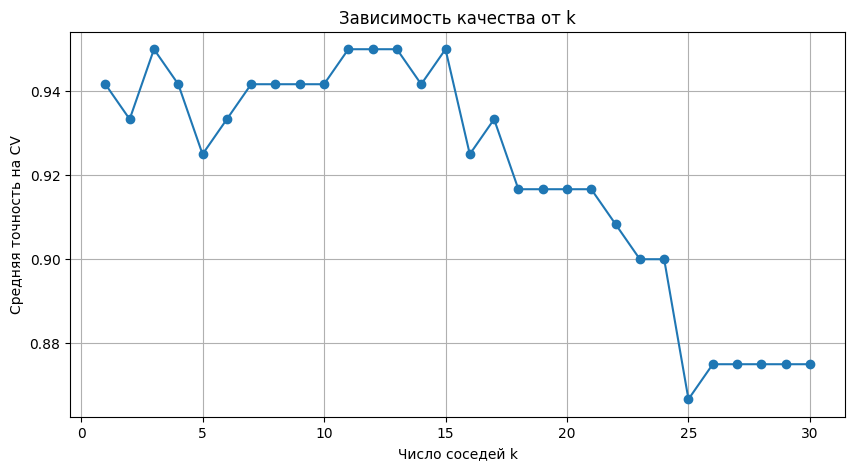

Оптимальное k по CV: 3 с точностью 0.950


In [ ]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

#построение графика
plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('Число соседей k')
plt.ylabel('Средняя точность на CV')
plt.title('Зависимость качества от k')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(cv_scores)]
print(f"Оптимальное k по CV: {best_k} с точностью {max(cv_scores):.3f}")
#мы видим, что наилучшая точность наблюдается при количестве соседей <= 15, а при кол-ве соседей  от 16 и выше точность в разы снижается

In [ ]:
param_grid = {          #определяем влияние типа весов и метрик
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность на CV:", grid_search.best_score_)



results = pd.DataFrame(grid_search.cv_results_)   #переводим результаты в DataFrame для анализа
results[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']].sort_values('mean_test_score', ascending=False)
#лучшие параметры с масштабированием показала метрика 'euclidian' при количестве соседей равному 9

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Лучшая точность на CV: 0.9583333333333334


,param_n_neighbors,param_weights,param_metric,mean_test_score
9,11,distance,euclidean,0.958333
7,9,distance,euclidean,0.958333
19,11,distance,manhattan,0.958333
17,9,distance,manhattan,0.958333
16,9,uniform,manhattan,0.958333
15,7,distance,manhattan,0.958333
29,11,distance,minkowski,0.958333
27,9,distance,minkowski,0.958333
12,5,uniform,manhattan,0.950000
13,5,distance,manhattan,0.950000


In [ ]:
grid_search_no_scale = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)    #сравнение с немасштабированными данными
grid_search_no_scale.fit(X_train, y_train)

print("Лучшие параметры (без масштабирования):", grid_search_no_scale.best_params_)
print("Лучшая точность на CV (без масштабирования):", grid_search_no_scale.best_score_)
#наилучшие результаты без масштабирования также показала метрика 'euclidian', но уже с количеством соседей равному 3

Лучшие параметры (без масштабирования): {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Лучшая точность на CV (без масштабирования): 0.9583333333333334


In [ ]:
best_knn = grid_search.best_estimator_   #подбор гиперпараметров
y_pred_best = best_knn.predict(X_test_scaled)

print("Лучшая модель KNN")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_best):.3f}")
print(classification_report(y_test, y_pred_best, target_names=target_names))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_best))

Лучшая модель KNN
Accuracy на тесте: 1.000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Матрица ошибок:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
